In [3]:
import jax
import jax.numpy as jnp
import optimistix as optx
import matplotlib.pyplot as plt

# ── Physical setup ──────────────────────────────────────────────────
y0 = 10.0
yf = 0.0
g  = 9.81
m  = 1.0

x_start, x_end = 0.0, 20.0
N   = 5000
dxs = jnp.full(N, (x_end - x_start) / N)

# ── Physics helpers ─────────────────────────────────────────────────
def speed(y, y0, g, m):
    return jnp.sqrt(jnp.maximum(2.0 * m * g * (y0 - y), 1e-8))

def cost_func(ys, dxs, y0, g, m):
    y_now  = ys[1:]
    y_prev = ys[:-1]
    speed_avg = 0.5 * (speed(y_now, y0, g, m) + speed(y_prev, y0, g, m))
    delta_s   = jnp.sqrt((y_now - y_prev) ** 2 + dxs ** 2)
    return jnp.sum(delta_s / speed_avg)

# ── Objective: signature must be fn(y, args) for optimistix ────────
#   y    → ys_interior, shape (N-1,)  — the free variables
#   args → everything else, passed through optimistix unchanged
def objective(ys_interior, args):
    dxs, y0, yf, g, m = args
    ys = jnp.concatenate([jnp.array([y0]), ys_interior, jnp.array([yf])])
    return cost_func(ys, dxs, y0, g, m)

# ── Pack args & initial guess ───────────────────────────────────────
args = (dxs, y0, yf, g, m)

ys_init_full     = jnp.linspace(y0, yf, N + 1)
ys_interior_init = ys_init_full[1:-1]          # shape (N-1,)

# ── Solve with optimistix ───────────────────────────────────────────
#   rtol/atol are the convergence tolerances
solver = optx.BFGS(rtol=1e-7, atol=1e-7)

sol = optx.minimise(
    fn       = objective,
    solver   = solver,
    y0       = ys_interior_init,
    args     = args,
    max_steps= 50000,
    throw    = True,   # raise on failure instead of returning silently
)

# ── Reconstruct full solution ───────────────────────────────────────
ys_opt = jnp.concatenate([jnp.array([y0]), sol.value, jnp.array([yf])])
xs     = jnp.linspace(x_start, x_end, N + 1)

print(f"Steps taken     : {sol.stats['num_steps']}")
print(f"Optimal time    : {objective(sol.value, args):.6f} s")


Steps taken     : 24792
Optimal time    : 2.547472 s


In [ ]:
# Gauss-Newton this

@jax.jit
def GN_solve(domain, steps=2000):
  H = jax.hessian(lambda y: objective(y, args=args))
  J = jax.jacfwd(lambda y: objective(y, args=args))
  def minHessian(x, i): 
      return x - 0.1*jnp.linalg.solve(H(x), J(x)), None

  domain, _ = jax.lax.scan(minHessian, domain, length=steps)
  
  return domain, objective(domain, args)
domain, minimum = GN_solve(ys_interior_init)
ys_opt_gn = jnp.concat([jnp.array([y0]), domain, jnp.array([yf])])
print(f"Gauss-Newton solution\nMinimum time : {minimum:.6f} s")

Gauss-Newton solution
Minimum time : 2.547451 s


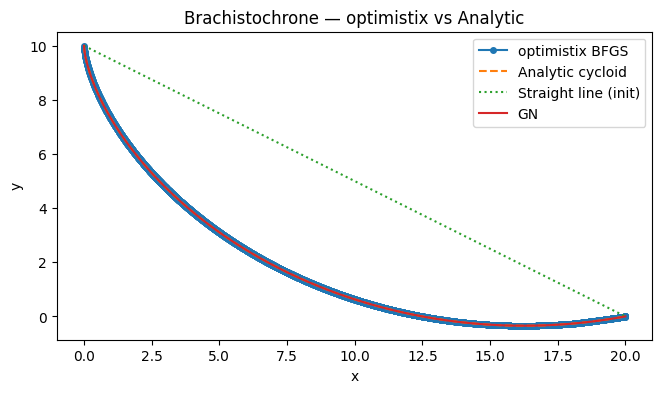

In [6]:

# ── Analytic cycloid for comparison ────────────────────────────────
def brachistochrone_analytic(x_end, y_drop, n=300):
    from scipy.optimize import brentq
    def eq(theta):
        R = y_drop / (1 - jnp.cos(theta))
        return float(R * (theta - jnp.sin(theta))) - x_end
    theta_end = brentq(eq, 0.01, 2 * float(jnp.pi) - 0.01)
    R      = float(y_drop / (1 - jnp.cos(theta_end)))
    thetas = jnp.linspace(0, theta_end, n)
    return R * (thetas - jnp.sin(thetas)), -R * (1 - jnp.cos(thetas))

x_a, y_a = brachistochrone_analytic(x_end, abs(yf- y0))

# ── Plot ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot()
ax.plot(xs,  ys_opt, 'o-', ms=4, label='optimistix BFGS')
ax.plot(x_a, y_a + abs(yf-y0),   '--',        label='Analytic cycloid')
ax.plot([x_start, x_end], [y0, yf], ':', label='Straight line (init)')
ax.plot(xs, ys_opt_gn, label='GN')
ax.set_aspect("equal")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Brachistochrone — optimistix vs Analytic')
ax.legend()
# ax.tight_layout()
